# Prompt-Cue Ablation — CEFR-Gated PMT

This notebook evaluates whether the performance of CEFR-Gated PrefixMemory-Tuning depends on explicit CEFR-related cues in the textual prompt.

The model architecture is unchanged from the CEFR-Gated PMT controller:

- frozen `meta-llama/Llama-3.1-8B-Instruct` backbone;
- one full `4096 × 4096` memory matrix per transformer layer;
- one trainable 4096-dimensional embedding per CEFR level;
- a learnable scalar `alpha`;
- multiplicative CEFR gating before memory retrieval.

The ablation removes the explicit A1/A2 and C1/C2 linguistic guidance from the textual prompt. The target CEFR level is therefore communicated only through the CEFR-specific architectural conditioning signal.

The notebook includes:

- training the prompt-cue-ablated CEFR-Gated PMT controller;
- validation-loss and perplexity tracking;
- publication of the trained checkpoint to Hugging Face;
- generation on the 702-condition In-Domain Evaluation Prompt Matrix;
- evaluation using the primary Joint-Loss CEFR evaluator;
- comparison with the full CEFR-Gated PMT configuration.

In [ ]:
# =========================================================
# 0. ENVIRONMENT SETUP & DEPENDENCIES
# =========================================================
!pip install -q transformers torch datasets huggingface_hub accelerate scikit-learn textstat spacy hf_transfer
!python -m spacy download en_core_web_sm

import os
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

import gc
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForCausalLM
from huggingface_hub import login, HfApi
from google.colab import drive, userdata
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 112.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 90.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 141.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


/usr/local/lib/python3.13/dist-packages/huggingface_hub/constants.py:299: FutureWarning: The `HF_HUB_ENABLE_HF_TRANSFER` environment variable is deprecated as 'hf_transfer' is not used anymore. Please use `HF_XET_HIGH_PERFORMANCE` instead to enable high performance transfer with Xet. Visit https://huggingface.co/docs/huggingface_hub/package_reference/environment_variables#hfxethighperformance for more details.
  warnings.warn(


In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

# Configure Path variables
BALANCED_CSV_PATH = "/content/drive/MyDrive/Your_Path/"
    "balanced_cefr_steering_subset.csv"

# 1- UPDATED: New Hugging Face Repository for Pure PMT
HF_REPO_ID = "MohammadKhosravi/llama3.1-8b-pure-pmt-cefr-gating-no-cefr-cues"

# 2- UPDATED: New Drive Log Directory
DRIVE_LOG_DIR = "/content/drive/MyDrive/Your_Path/"
    "prompt_cue_ablation_training_logs"
os.makedirs(DRIVE_LOG_DIR, exist_ok=True)

try:
    hf_token = userdata.get('HF_TOKEN')
    login(token=hf_token)
except Exception:
    pass

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using execution device: {device}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using execution device: cuda


In [ ]:
# ==========================================
# 1. INGEST BALANCED DATASET
# ==========================================
print(f"\n📥 Ingesting pre-balanced topic-aligned dataset from: {BALANCED_CSV_PATH}")
balanced_df = pd.read_csv(BALANCED_CSV_PATH).dropna(subset=['cefr', 'clean_text', 'topic_title'])
balanced_df['cefr'] = balanced_df['cefr'].str.upper().str.strip()

label_map = {"A1": 0, "A2": 1, "B1": 2, "B2": 3, "C1": 4, "C2": 5}


📥 Ingesting pre-balanced topic-aligned dataset from: /content/drive/MyDrive/Mohammd_Thesis/subsets/efcamdat_balanced_subset_training.csv


In [ ]:
# ==========================================
# 2. LOAD FROZEN BASE LLM & TOKENIZER
# ==========================================
print("\nLoading Llama-3.1-8B-Instruct...")
model_id = "meta-llama/Llama-3.1-8B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.padding_side = "right"
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Load safely on CUDA to prevent CPU memory-swap overhead
base_model = AutoModelForCausalLM.from_pretrained(
    model_id, torch_dtype=torch.bfloat16, device_map={"": torch.cuda.current_device()}
)
for param in base_model.parameters():
    param.requires_grad = False
base_model.eval()


Loading Llama-3.1-8B-Instruct...


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((4096,), eps=1e-05)
  

In [ ]:
# ==========================================
# 3. PURE PREFIXMEMORY-TUNING & HOOKS
# ==========================================
class PureCEFRPMTController(nn.Module):
    def __init__(self, num_layers=32, hidden_dim=4096, num_classes=6):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        # Learnable scaling parameter for optimization stability
        self.alpha = nn.Parameter(torch.tensor(0.1))

        # 1. CEFR Level Embeddings (The "Knob"): Shape [6, 4096]
        self.cefr_embeddings = nn.Embedding(num_classes, hidden_dim)

        # 2. Pure PMT Memory Matrices: Shape [32, 4096, 4096]
        # (Total Parameters: ~536.8 Million)
        self.M = nn.Parameter(torch.randn(num_layers, hidden_dim, hidden_dim) * (hidden_dim ** -0.5))

    def forward(self, cefr_ids):
        # Retrieve the 4096-dim vector for the batch's CEFR levels
        # Shape: [Batch, 4096]
        return self.cefr_embeddings(cefr_ids)

prefix_memory_controller = PureCEFRPMTController().to(device).to(torch.bfloat16)
current_batch_cefr_vector = None

def make_pure_pmt_hook(layer_idx):
    def hook_fn(module, args, kwargs, output):
        global current_batch_cefr_vector
        if current_batch_cefr_vector is None: return output

        # Safely extract input hidden states (X)
        if len(args) > 0:
            hidden_states = args[0]
        elif 'hidden_states' in kwargs:
            hidden_states = kwargs['hidden_states']
        else:
            return output

        attn_output = output[0] # [Batch, Seq, 4096]

        if current_batch_cefr_vector.shape[0] != attn_output.shape[0]: return output

        # 1. Apply Feature Map: ELU(X) -> Shape [Batch, Seq, 4096]
        phi_X = F.elu(hidden_states)

        # 2. Modulate/Gate with CEFR vector: [Batch, Seq, 4096] * [Batch, 1, 4096]
        gated_X = phi_X * current_batch_cefr_vector.unsqueeze(1)

        # 3. Retrieve Memory Matrix for this layer: [4096, 4096]
        M_l = prefix_memory_controller.M[layer_idx]

        # 4. Multiply to get Bias_mem: [Batch, Seq, 4096]
        prefix_memory_bias = torch.matmul(gated_X, M_l)

        # 5. Injection: Z_pmt = Z + alpha * Bias_mem
        final_attn_output = attn_output + (prefix_memory_controller.alpha * prefix_memory_bias)

        return (final_attn_output,) + output[1:]
    return hook_fn

# Register the Pure PrefixMemory hooks
for i in range(32):
    base_model.model.layers[i].self_attn.register_forward_hook(make_pure_pmt_hook(i), with_kwargs=True)


In [ ]:
# ==========================================
# 4. TOPIC-ALIGNED DATA LOADERS
# ==========================================
class CEFRTopicDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=256):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        cefr_str = str(row['cefr']).strip().upper()
        topic_title = str(row['topic_title']).strip()

        prompt = (
            f"You are an expert English language teacher demonstrating CEFR proficiency levels. "
            f"Your task is to write a flawless, grammatically correct text responding to this prompt: '{topic_title}'. "
            f"Write only the direct response. Do not write any meta-commentary, greetings, or conversational pleasantries."
        )

        messages = [{"role": "user", "content": prompt}]
        formatted_prompt = self.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

        full_text = formatted_prompt + str(row['clean_text']).strip() + self.tokenizer.eos_token

        prompt_enc = self.tokenizer(formatted_prompt, add_special_tokens=False)
        full_enc = self.tokenizer(full_text, truncation=True, max_length=self.max_length, padding='max_length')

        labels = list(full_enc['input_ids'])
        prompt_len = len(prompt_enc['input_ids'])
        for i in range(min(prompt_len, self.max_length)):
            labels[i] = -100

        return {
            "input_ids": torch.tensor(full_enc['input_ids'], dtype=torch.long),
            "attention_mask": torch.tensor(full_enc['attention_mask'], dtype=torch.long),
            "labels": torch.tensor(labels, dtype=torch.long),
            "cefr_id": torch.tensor(label_map.get(cefr_str, 0), dtype=torch.long)
        }

train_df, val_df = train_test_split(balanced_df, test_size=0.10, stratify=balanced_df['cefr'], random_state=42)
train_loader = DataLoader(CEFRTopicDataset(train_df, tokenizer), batch_size=8, shuffle=True)
val_loader = DataLoader(CEFRTopicDataset(val_df, tokenizer), batch_size=8, shuffle=False)

In [ ]:
# ==========================================
# 5. OPTIMIZATION & BEST-MODEL TRACKING
# ==========================================
optimizer = torch.optim.AdamW(prefix_memory_controller.parameters(), lr=2e-4)
epochs = 3
best_val_loss = float('inf')
best_model_path = "./best_pure_pmt_gating_weights.pt"
training_summary_logs = []

print("\n🚀 Launching End-to-End Pure PMT + CEFR Gating...")
for epoch in range(epochs):
    prefix_memory_controller.train()
    total_loss = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    for batch in progress_bar:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        cefr_ids = batch['cefr_id'].to(device)

        global current_batch_cefr_vector
        current_batch_cefr_vector = prefix_memory_controller(cefr_ids)

        outputs = base_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix({"Loss": f"{loss.item():.4f}"})

    # Validation Loop
    prefix_memory_controller.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            cefr_ids = batch['cefr_id'].to(device)

            current_batch_cefr_vector = prefix_memory_controller(cefr_ids)

            outputs = base_model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            val_loss += outputs.loss.item()

    avg_train_loss = total_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    val_ppl = np.exp(avg_val_loss)

    epoch_metrics = {
        "epoch": epoch + 1,
        "train_loss": round(avg_train_loss, 4),
        "val_loss": round(avg_val_loss, 4),
        "val_ppl": round(val_ppl, 2)
    }
    training_summary_logs.append(epoch_metrics)

    print(f"📈 [Epoch {epoch+1}/{epochs}] Complete | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val PPL: {val_ppl:.2f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(prefix_memory_controller.state_dict(), best_model_path)
        print(f"🌟 Validation improved! New best model checkpoint locked.")

# Save training summary JSON locally and to Google Drive
json_log_path = os.path.join(DRIVE_LOG_DIR, "training_summary.json")
with open(json_log_path, "w") as f:
    json.dump(training_summary_logs, f, indent=4)
print(f"\n📊 Detailed training summary logs saved to Drive: {json_log_path}")



🚀 Launching End-to-End Pure PMT + CEFR Gating...


Epoch 1/3:   0%|          | 0/627 [00:00<?, ?it/s]

📈 [Epoch 1/3] Complete | Train Loss: 2.1370 | Val Loss: 1.8798 | Val PPL: 6.55
🌟 Validation improved! New best model checkpoint locked.


Epoch 2/3:   0%|          | 0/627 [00:00<?, ?it/s]

📈 [Epoch 2/3] Complete | Train Loss: 1.5536 | Val Loss: 1.8392 | Val PPL: 6.29
🌟 Validation improved! New best model checkpoint locked.


Epoch 3/3:   0%|          | 0/627 [00:00<?, ?it/s]

📈 [Epoch 3/3] Complete | Train Loss: 1.0606 | Val Loss: 2.0055 | Val PPL: 7.43

📊 Detailed training summary logs saved to Drive: /content/drive/MyDrive/Mohammd_Thesis/Training_Logs/Pure_PMT_Embedding_Gating_No_CEFR_Cues/training_summary.json


In [ ]:
# ==========================================
# 6. EXPORT TO HUGGING FACE
# ==========================================
local_output_dir = "./pure_pmt_gating_hf_export"
os.makedirs(local_output_dir, exist_ok=True)

prefix_memory_controller.load_state_dict(torch.load(best_model_path))
torch.save(prefix_memory_controller.state_dict(), os.path.join(local_output_dir, "pure_pmt_controller_weights.pt"))

with open(os.path.join(local_output_dir, "training_summary.json"), "w") as f:
    json.dump(training_summary_logs, f, indent=4)

# 3- UPDATED: Hugging Face README Explanation
readme_content = f"""---
license: mit
base_model: {model_id}
tags:
- peft
- prefixmemory-tuning
- cefr-alignment
- topic-aligned
- pure-pmt-gating
---
# Pure PrefixMemory-Tuning (PMT) + CEFR Gating

This experiment implements a highly faithful replication of the uncompressed PrefixMemory-Tuning architecture (arXiv:2506.13674), featuring independent full-dimensional memory matrices per layer 4096*4096.

## Architecture Details
1. **Uncompressed PMT:** Eliminates low-rank bottleneck projections in favor of the pure memory matrix parameterization (yielding ~536.9M trainable parameters).
2. **Explicit CEFR Feature Gating:** Uses a trainable 4096-dimensional CEFR embedding to element-wise modulate the ELU feature map before querying the layer memory.
3. **Topic Alignment:** Prompt contexts incorporate `topic_title` directly.
4. **Blind Level Control:** The textual prompt contains NO target CEFR level instructions.
5. **Loss:** Standard cross-entropy causal language modeling loss on balanced target tokens.

## Training Performance
```json
{json.dumps(training_summary_logs, indent=2)}
"""

with open(os.path.join(local_output_dir, "README.md"), "w") as f:
  f.write(readme_content)

print("\n📦 Pushing verified assets to Hugging Face repository...")
try:
  api = HfApi(token=hf_token)
  api.create_repo(repo_id=HF_REPO_ID, repo_type="model", exist_ok=True)
  api.upload_folder(
  folder_path=local_output_dir,
  repo_id=HF_REPO_ID,
  repo_type="model",
  commit_message=f"Upload Pure PMT + Gating weights no CEFR cues (Val PPL: {np.exp(best_val_loss):.2f})"
  )
  print(f"🚀 SUCCESS! Model weights deployed to: https://huggingface.co/{HF_REPO_ID}")
except Exception as e:
  print(f"⚠️ Export failed: {str(e)}")


📦 Pushing verified assets to Hugging Face repository...
🚀 SUCCESS! Model weights deployed to: https://huggingface.co/MohammadKhosravi/llama3.1-8b-pure-pmt-cefr-gating-no-cefr-cues


## In-Domain Generation and Evaluation

In [ ]:
# =========================================================
# 0. ENVIRONMENT SETUP & MANIFOLD INITIALIZATION
# =========================================================
!pip install -q transformers torch datasets tqdm huggingface_hub accelerate scikit-learn textstat spacy hf_transfer
!python -m spacy download en_core_web_sm

import os
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

import gc
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import spacy
import textstat
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModelForSequenceClassification
from huggingface_hub import login, hf_hub_download
from google.colab import drive, userdata
from tqdm import tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 128.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 113.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 127.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


/usr/local/lib/python3.13/dist-packages/huggingface_hub/constants.py:299: FutureWarning: The `HF_HUB_ENABLE_HF_TRANSFER` environment variable is deprecated as 'hf_transfer' is not used anymore. Please use `HF_XET_HIGH_PERFORMANCE` instead to enable high performance transfer with Xet. Visit https://huggingface.co/docs/huggingface_hub/package_reference/environment_variables#hfxethighperformance for more details.
  warnings.warn(


In [ ]:
# Mount Storage Systems
drive.mount('/content/drive')

# Explicit Experimental Target Paths
INPUT_CSV = "/content/drive/MyDrive/Your_Path/"
    "in_domain_evaluation_prompt_matrix.csv"
OUTPUT_DIR = "/content/drive/MyDrive/Your_Path/"
    "prompt_cue_ablation_evaluation_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

OUTPUT_CSV_PATH = os.path.join(OUTPUT_DIR, "benchmark_results_log.csv")
OUTPUT_TXT_PATH = os.path.join(OUTPUT_DIR, "overall_metrics_report.txt")
OUTPUT_IMG_PATH = os.path.join(OUTPUT_DIR, "confusion_matrix.png")

try:
    hf_token = userdata.get('HF_TOKEN')
    login(token=hf_token)
except Exception:
    pass

device = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32

label_map = {"A1": 0, "A2": 1, "B1": 2, "B2": 3, "C1": 4, "C2": 5}
inv_label_map = {v: k for k, v in label_map.items()}

Mounted at /content/drive


In [ ]:
# ==========================================
# 1. LOAD MODEL ARCHITECTURE & REGISTRATION HOOKS
# ==========================================
print("\n[1/3] Loading Pure PrefixMemory Generation Framework...")
model_id = "meta-llama/Llama-3.1-8B-Instruct"

# Left padding is mathematically required for batch generation loops
tokenizer = AutoTokenizer.from_pretrained(model_id, padding_side="left")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    model_id, torch_dtype=torch.bfloat16, device_map="auto"
)
base_model.eval()

# Pure PMT Controller Definition (Matching Pure PMT + CEFR Gating)
class PureCEFRPMTController(nn.Module):
    def __init__(self, num_layers=32, hidden_dim=4096, num_classes=6):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        self.alpha = nn.Parameter(torch.tensor(0.1))
        self.cefr_embeddings = nn.Embedding(num_classes, hidden_dim)
        self.M = nn.Parameter(torch.randn(num_layers, hidden_dim, hidden_dim) * (hidden_dim ** -0.5))

    def forward(self, cefr_ids):
        return self.cefr_embeddings(cefr_ids)

prefix_memory_controller = PureCEFRPMTController().to(device).to(torch.bfloat16)

print("Downloading Pure PrefixMemory controller parameter weights from Hub...")
weights_path = hf_hub_download(
    repo_id="MohammadKhosravi/llama3.1-8b-pure-pmt-cefr-gating-no-cefr-cues",
    filename="pure_pmt_controller_weights.pt"
)
prefix_memory_controller.load_state_dict(torch.load(weights_path, map_location=device))
prefix_memory_controller.eval()

current_batch_cefr_vector = None

def make_pure_pmt_hook(layer_idx):
    def hook_fn(module, args, kwargs, output):
        global current_batch_cefr_vector
        if current_batch_cefr_vector is None: return output

        if len(args) > 0:
            hidden_states = args[0]
        elif 'hidden_states' in kwargs:
            hidden_states = kwargs['hidden_states']
        else:
            return output

        attn_output = output[0] # [Batch, Seq, 4096]

        if current_batch_cefr_vector.shape[0] != attn_output.shape[0]: return output

        # 1. Apply Feature Map: ELU(X) -> Shape [Batch, Seq, 4096]
        phi_X = F.elu(hidden_states)

        # 2. Modulate/Gate with CEFR vector: [Batch, Seq, 4096] * [Batch, 1, 4096]
        gated_X = phi_X * current_batch_cefr_vector.unsqueeze(1)

        # 3. Retrieve Memory Matrix for layer: [4096, 4096]
        M_l = prefix_memory_controller.M[layer_idx]

        # 4. Compute Memory Bias: [Batch, Seq, 4096]
        prefix_memory_bias = torch.matmul(gated_X, M_l)

        # 5. Injection: Z_pmt = Z + alpha * Bias_mem
        final_attn_output = attn_output + (prefix_memory_controller.alpha * prefix_memory_bias)

        return (final_attn_output,) + output[1:]
    return hook_fn

# Register the Pure PrefixMemory hooks across all 32 layers
for i in range(32):
    base_model.model.layers[i].self_attn.register_forward_hook(make_pure_pmt_hook(i), with_kwargs=True)


[1/3] Loading Pure PrefixMemory Generation Framework...


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

pure_pmt_controller_weights.pt: reconstructing file:   0%|          |  0.00B / 1.07GB            

pure_pmt_controller_weights.pt: downloading bytes:           |  0.00B            

In [ ]:
# ==========================================
# 2. PHASE 1: GENERATION LOOP (BLIND PROMPTS)
# ==========================================
print("\n[2/3] Initiating Batch Generation Phase...")
df = pd.read_csv(INPUT_CSV)
generated_records = []

for b_start in tqdm(range(0, len(df), BATCH_SIZE), desc="Processing Prompt Batches"):
    batch_df = df.iloc[b_start : b_start + BATCH_SIZE]
    batch_prompts = []
    batch_cefrs = []

    for _, row in batch_df.iterrows():
        t_cefr = str(row['cefr']).strip().upper()
        batch_cefrs.append(t_cefr)

        prompt = (
            f"You are an expert English language teacher demonstrating CEFR proficiency levels. "
            f"Your task is to write a flawless, grammatically correct text responding to this prompt: '{row['topic_title']}'. "
            f"Write only the direct response. Do not write any meta-commentary, greetings, or conversational pleasantries."
        )
        messages = [{"role": "user", "content": prompt}]
        batch_prompts.append(tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True))

    inputs = tokenizer(batch_prompts, padding=True, return_tensors="pt").to(device)
    cefr_tensor = torch.tensor([label_map[c] for c in batch_cefrs], device=device)

    with torch.no_grad():
        global current_batch_cefr_vector
        current_batch_cefr_vector = prefix_memory_controller(cefr_tensor)

        output_ids = base_model.generate(
            **inputs,
            max_new_tokens=200,
            temperature=0.6,
            do_sample=True,
            eos_token_id=tokenizer.eos_token_id
        )

    for i, output_id in enumerate(output_ids):
        gen_tokens = output_id[inputs.input_ids.shape[1]:]
        gen_text = tokenizer.decode(gen_tokens, skip_special_tokens=True).strip()

        generated_records.append({
            "topic_id": batch_df.iloc[i]['topic_id'],
            "topic_title": batch_df.iloc[i]['topic_title'],
            "target_cefr": batch_cefrs[i],
            "generated_text": gen_text
        })

# Total memory purge to optimize footprint space for the Judge Evaluation
del base_model
del prefix_memory_controller
torch.cuda.empty_cache()
gc.collect()



[2/3] Initiating Batch Generation Phase...


Processing Prompt Batches: 100%|██████████| 22/22 [09:07<00:00, 24.87s/it]


202

In [ ]:
# ==========================================
# 3. PHASE 2: EVALUATION AND LINGUISTIC NLP METRICS
# ==========================================
print("\n[3/3] Initiating Post-Generation Evaluation Loop...")
nlp = spacy.load("en_core_web_sm")

print("Deploying Custom JointLoss RoBERTa Evaluator Matrix...")
JUDGE_MODEL_ID = "MohammadKhosravi/roberta-large-cefr-classifier-JointLoss"
judge_tokenizer = AutoTokenizer.from_pretrained(JUDGE_MODEL_ID)
judge_model = AutoModelForSequenceClassification.from_pretrained(JUDGE_MODEL_ID).to(device)
judge_model.eval()

def calculate_mdd(text):
    doc = nlp(text)
    total_dist, tokens = 0, 0
    for token in doc:
        if token.dep_ != "punct":
            total_dist += abs(token.i - token.head.i)
            tokens += 1
    return total_dist / tokens if tokens > 0 else 0.0

def calculate_sentence_drift(text):
    doc = nlp(text)
    sentences = [sent.text.strip() for sent in doc.sents if len(sent.text.strip()) > 10]
    if len(sentences) <= 1: return 0
    inputs = judge_tokenizer(sentences, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
    with torch.no_grad():
        preds = torch.argmax(judge_model(**inputs).logits, dim=-1).cpu().numpy()
    return int(np.max(preds) - np.min(preds))

final_results = []

for record in tqdm(generated_records, desc="Extracting Metrics"):
    gen_text = record["generated_text"]
    target_cefr = record["target_cefr"]

    if not gen_text:
        gen_text = "Empty response generation failure."

    eval_inputs = judge_tokenizer(gen_text, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
    with torch.no_grad():
        eval_pred = torch.argmax(judge_model(**eval_inputs).logits, dim=-1).item()
    predicted_cefr = inv_label_map[eval_pred]

    is_strict = int(predicted_cefr == target_cefr)
    is_adjacent = int(abs(label_map[predicted_cefr] - label_map[target_cefr]) <= 1)

    try: flesch_score = textstat.flesch_reading_ease(gen_text)
    except: flesch_score = 0.0
    mdd_score = calculate_mdd(gen_text)
    drift_score = calculate_sentence_drift(gen_text)

    final_results.append({
        "topic_id": record["topic_id"],
        "topic_title": record["topic_title"],
        "target_cefr": target_cefr,
        "predicted_cefr": predicted_cefr,
        "strict_match": is_strict,
        "adjacent_match": is_adjacent,
        "mdd": round(mdd_score, 2),
        "readability_flesch": round(flesch_score, 2),
        "sentence_drift_max": drift_score,
        "generated_text": gen_text
    })

# Format and save the execution Log csv file
df_final = pd.DataFrame(final_results)
df_final.to_csv(OUTPUT_CSV_PATH, index=False)
print(f"✔️ Detailed execution log saved to: {OUTPUT_CSV_PATH}")




[3/3] Initiating Post-Generation Evaluation Loop...
Deploying Custom JointLoss RoBERTa Evaluator Matrix...


config.json:   0%|          | 0.00/900 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/388 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.56M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.42GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Extracting Metrics: 100%|██████████| 702/702 [00:58<00:00, 11.94it/s]

✔️ Detailed execution log saved to: /content/drive/MyDrive/Mohammd_Thesis/Results/Prefix_Tuning/2-Pure_PMT_Embedding_Gating/Trained_On_Small_Balanced_dataset-6K/No_Prompt_Cue/benchmark_results_log.csv


 📊 FINAL COMPILED MACRO-STATISTICS (PURE PMT + CEFR GATING)
Total Processed       : 702
Strict Accuracy       : 63.11%
Adjacent Accuracy     : 78.06%
Mean Abs Error (MAE)  : 0.7407
Avg MDD Score         : 1.78
Avg Reading Ease      : 80.62
Avg Sentence Drift    : 2.36 levels
Avg Perplexity        : (Computed externally)

📈 PERFORMANCE BREAKDOWN BY CEFR TARGET LEVEL:
             strict_accuracy  avg_mdd  avg_flesch  avg_drift
target_cefr                                                 
A1                     84.62     1.55       82.34       0.62
A2                     72.65     1.67       85.79       1.87
B1                     77.78     1.83       82.25       2.51
B2                     70.94     1.90       76.62       2.71
C1                     47.86     1.83       76.62       3.32
C2                     24.79     1.92       80.07       3.14

📝 DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

          A1       0.72      0.85      0.78       117

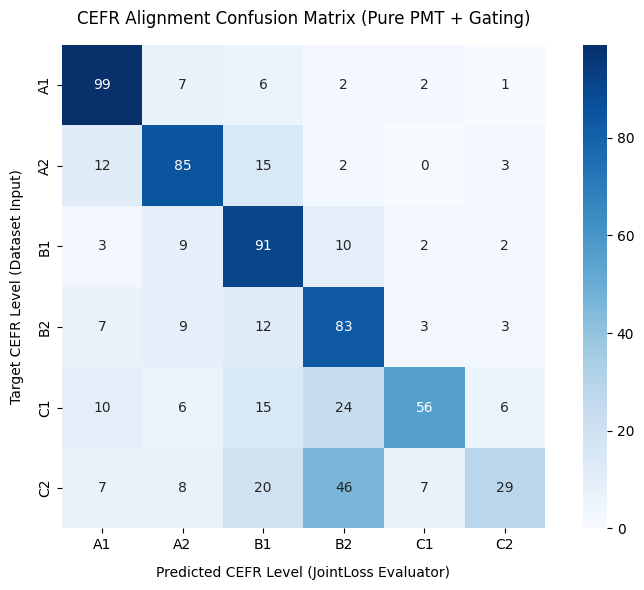

In [ ]:
# ==========================================
# 4. REPORT EXPORT GENERATION
# ==========================================
y_true = df_final['target_cefr']
y_pred = df_final['predicted_cefr']

strict_acc = df_final['strict_match'].mean() * 100
adj_acc = df_final['adjacent_match'].mean() * 100
mae = mean_absolute_error(y_true.map(label_map), y_pred.map(label_map))
avg_mdd = df_final['mdd'].mean()
avg_flesch = df_final['readability_flesch'].mean()
avg_drift = df_final['sentence_drift_max'].mean()

report_text = "="*60 + "\n"
report_text += " 📊 FINAL COMPILED MACRO-STATISTICS (PURE PMT + CEFR GATING)\n"
report_text += "="*60 + "\n"
report_text += f"Total Processed       : {len(df_final)}\n"
report_text += f"Strict Accuracy       : {strict_acc:.2f}%\n"
report_text += f"Adjacent Accuracy     : {adj_acc:.2f}%\n"
report_text += f"Mean Abs Error (MAE)  : {mae:.4f}\n"
report_text += f"Avg MDD Score         : {avg_mdd:.2f}\n"
report_text += f"Avg Reading Ease      : {avg_flesch:.2f}\n"
report_text += f"Avg Sentence Drift    : {avg_drift:.2f} levels\n"
report_text += "Avg Perplexity        : (Computed externally)\n"
report_text += "="*60 + "\n\n"

report_text += "📈 PERFORMANCE BREAKDOWN BY CEFR TARGET LEVEL:\n"
level_agg = df_final.groupby("target_cefr").agg(
    strict_accuracy=("strict_match", lambda x: np.mean(x) * 100),
    avg_mdd=("mdd", "mean"),
    avg_flesch=("readability_flesch", "mean"),
    avg_drift=("sentence_drift_max", "mean")
).round(2)
report_text += level_agg.to_string() + "\n\n"

report_text += "="*60 + "\n"
report_text += "📝 DETAILED CLASSIFICATION REPORT:\n"
cefr_labels = ["A1", "A2", "B1", "B2", "C1", "C2"]
report_text += classification_report(y_true, y_pred, labels=cefr_labels, zero_division=0)
report_text += "\n" + "="*60 + "\n"

# Output and write the TXT file locally
with open(OUTPUT_TXT_PATH, "w") as f:
    f.write(report_text)
print(report_text)

# Plot and export the Confusion Matrix file
cm = confusion_matrix(y_true, y_pred, labels=cefr_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cefr_labels, yticklabels=cefr_labels, cbar=True, square=True)
plt.title("CEFR Alignment Confusion Matrix (Pure PMT + Gating)", fontsize=12, pad=15)
plt.xlabel("Predicted CEFR Level (JointLoss Evaluator)", fontsize=10, labelpad=10)
plt.ylabel("Target CEFR Level (Dataset Input)", fontsize=10, labelpad=10)
plt.tight_layout()
plt.savefig(OUTPUT_IMG_PATH, dpi=300)
print(f"🎨 Confusion Matrix plot successfully saved to: {OUTPUT_IMG_PATH}")